In [41]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("CTG DATA CLUSTERING PIPELINE (No PCA)")
print("=" * 80)
df=pd.read_excel('CTG.xls',sheet_name=1)

CTG DATA CLUSTERING PIPELINE (No PCA)


In [29]:
df['Unnamed: 9'].isnull().sum()

2130

In [30]:
print(df.columns.tolist())

['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 22, 'Unnamed: 44', 23]


In [31]:
# Fix headers
df.columns = df.iloc[0]
df = df.iloc[1:]
df = df.reset_index(drop=True)

empty_cols = ['Unnamed: 9', 'Unnamed: 42', 'Unnamed: 44']

df = df.drop(columns=empty_cols, errors='ignore')

# Remove summary row
df = df.iloc[:-1]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (2128, 46)


In [48]:
df=pd.read_excel('CTG.xls',sheet_name='Raw Data')

In [49]:
# Define features and target - ONLY these 21 columns
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

target_col = 'NSP'

# Extract only the feature columns we want
available_features = [col for col in feature_cols if col in df.columns]
print(f"   Available features: {len(available_features)}/{len(feature_cols)}")

X = df[available_features].copy()
y_raw = df[target_col].copy()

print(f"   Features: {len(available_features)}")



   Available features: 21/21
   Features: 21


In [50]:
#:Handle NaN in y
print(f"\n   Checking target variable (NSP):")
print(f"     Original shape: {y_raw.shape}")
print(f"     NaN count in y: {y_raw.isna().sum()}")

# Remove rows where y is NaN
valid_mask = ~y_raw.isna()
X = X[valid_mask].copy()
y = y_raw[valid_mask].copy()

print(f"     After removing NaN: {len(y)} samples")

# Convert y to integer type
y = y.astype(int)

print(f"     Target classes: {np.unique(y)} (1=Normal, 2=Suspicious, 3=Pathological)")

# Target distribution
print(f"\n   Target Distribution (NSP - Fetal Health):")
class_counts = y.value_counts().sort_index()
for cls, count in class_counts.items():
    class_name = {1: 'Normal', 2: 'Suspicious', 3: 'Pathological'}.get(cls, 'Unknown')
    print(f"     Class {cls} ({class_name}): {count} samples ({count/len(y)*100:.1f}%)")


   Checking target variable (NSP):
     Original shape: (2130,)
     NaN count in y: 4
     After removing NaN: 2126 samples
     Target classes: [1 2 3] (1=Normal, 2=Suspicious, 3=Pathological)

   Target Distribution (NSP - Fetal Health):
     Class 1 (Normal): 1655 samples (77.8%)
     Class 2 (Suspicious): 295 samples (13.9%)
     Class 3 (Pathological): 176 samples (8.3%)


In [51]:
# Feature scaling (StandardScaler - critical for distance-based algorithms)

print("\n[3] Feature scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"   Scaled data shape: {X_scaled_df.shape}")
print(f"   Mean after scaling: {X_scaled_df.mean().mean():.2e}")
print(f"   Std after scaling: {X_scaled_df.std().mean():.2f}")


[3] Feature scaling...
   Scaled data shape: (2126, 21)
   Mean after scaling: 1.20e-17
   Std after scaling: 1.00


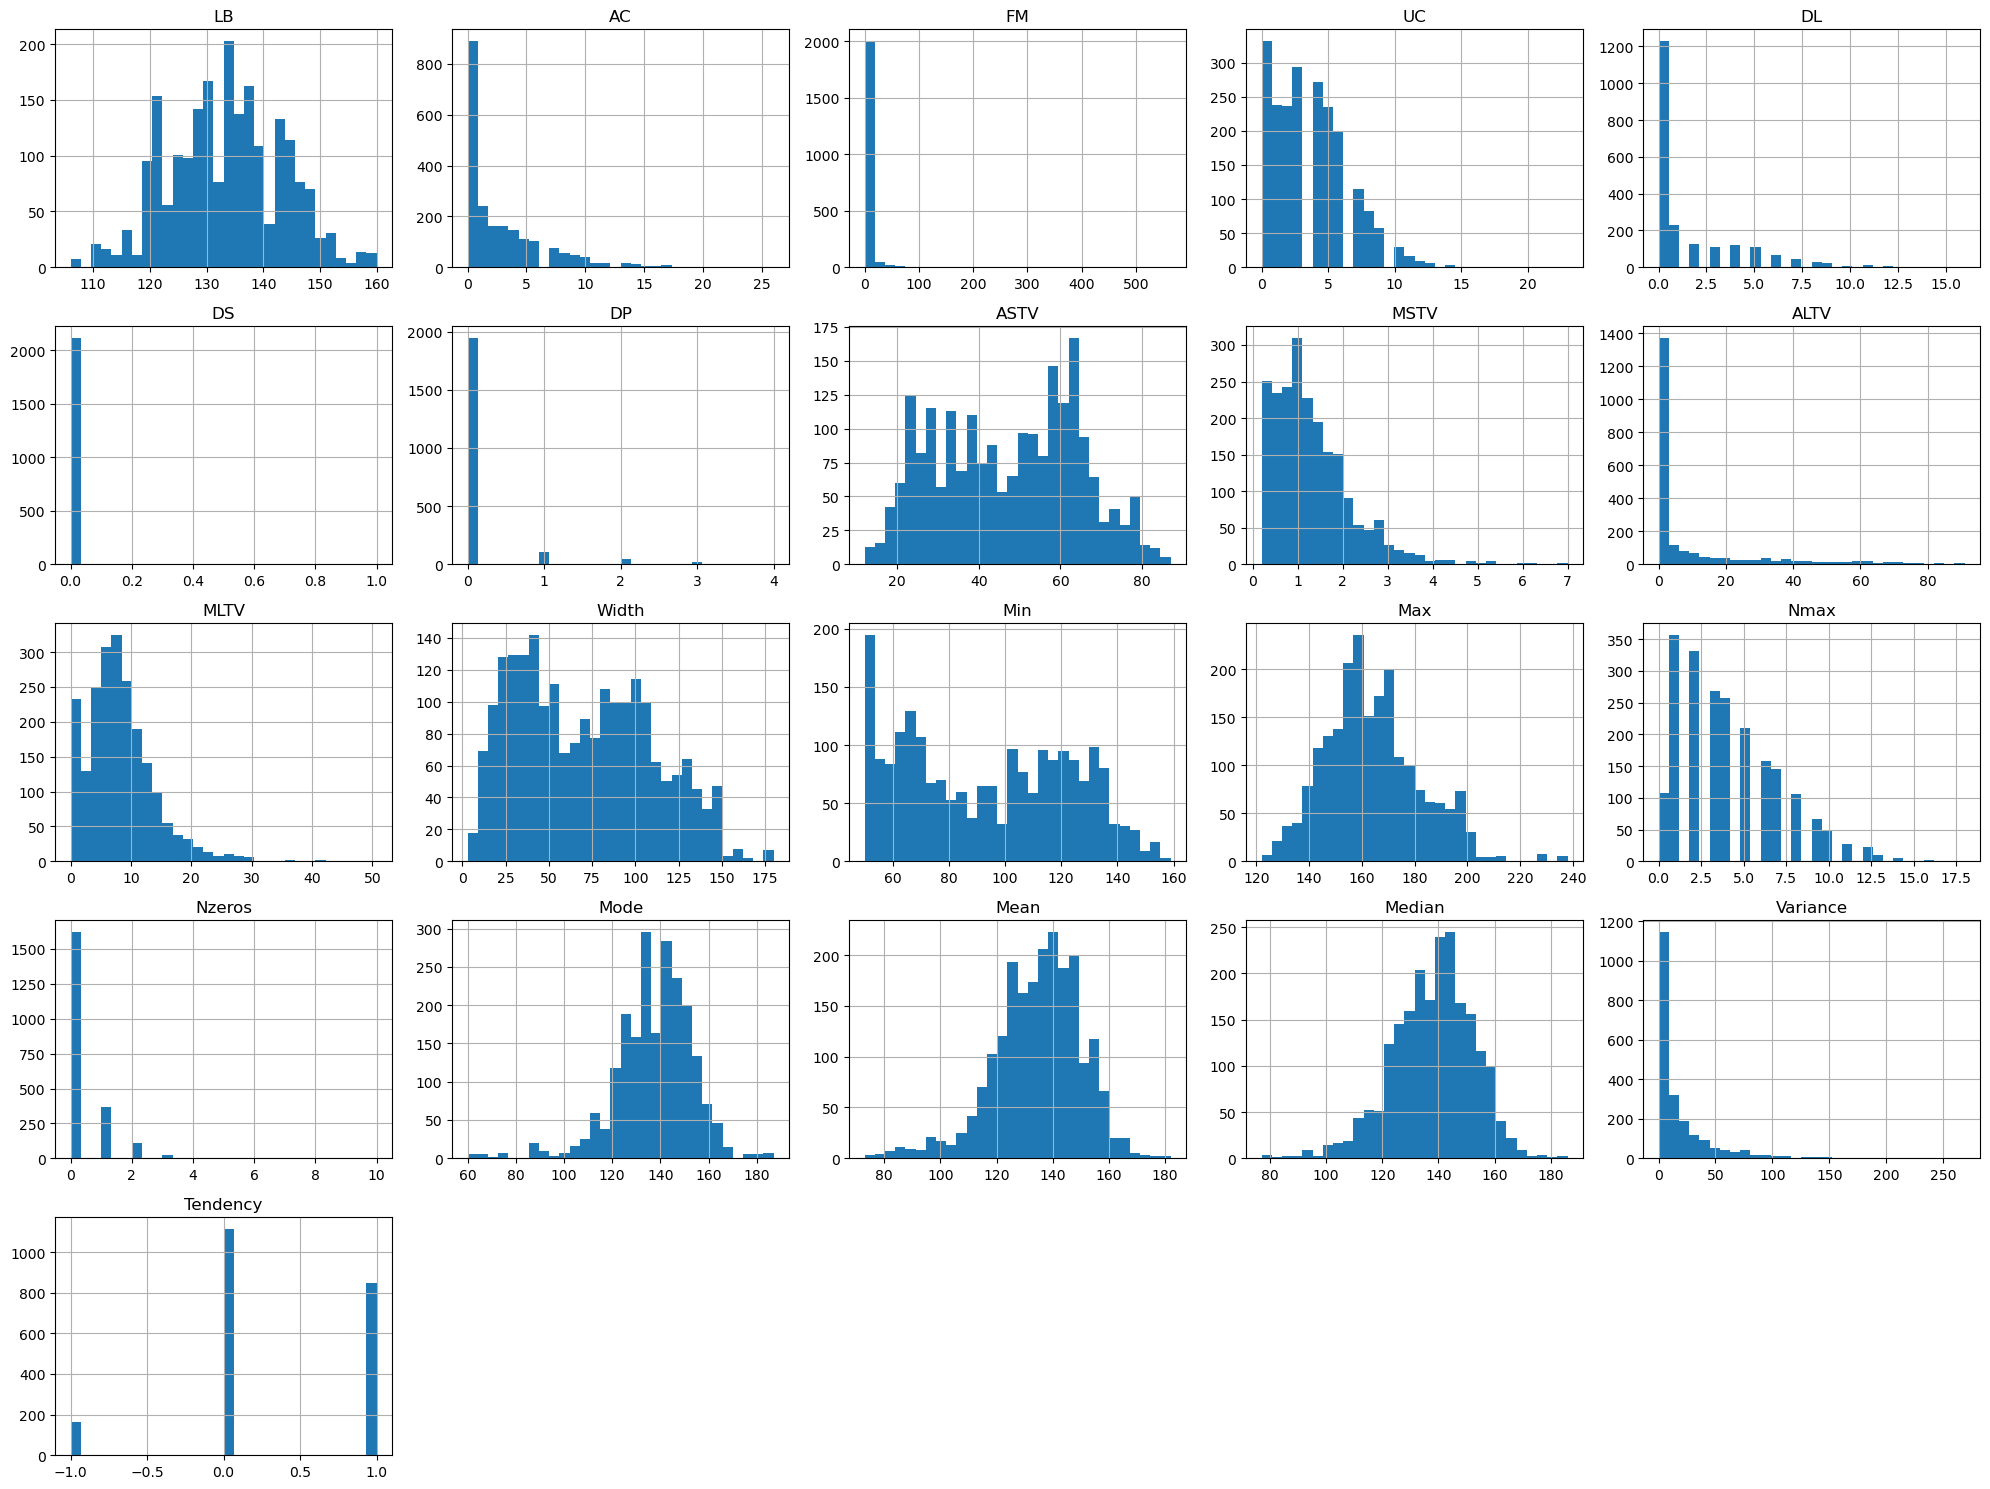

In [52]:
# Exploratory Data Analysis

# Feature distributions (histograms)

import matplotlib.pyplot as plt

X_imputed.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

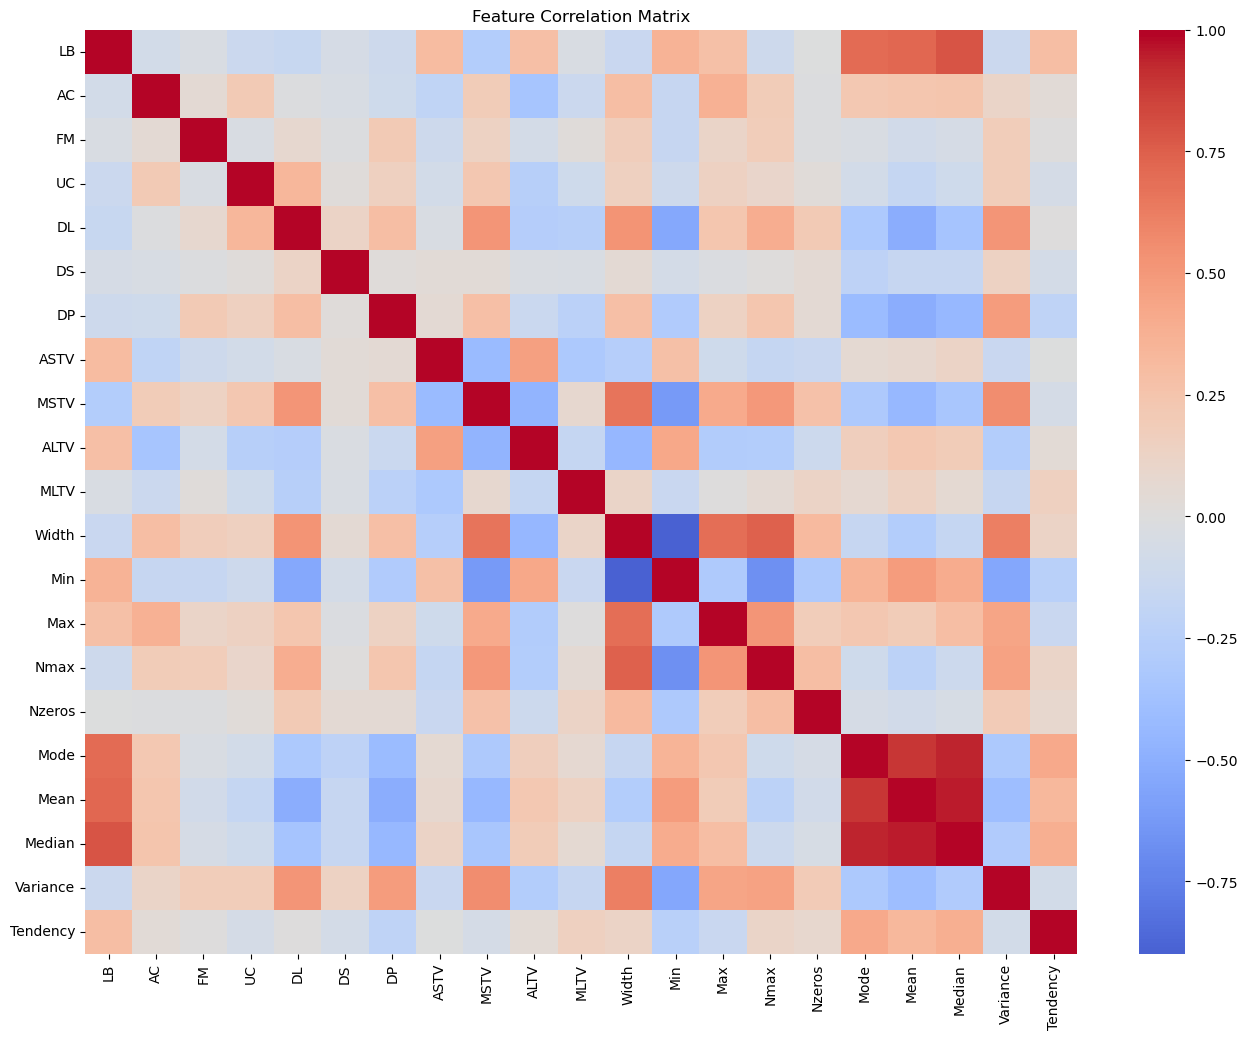

In [53]:
# Correlation heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(X_imputed.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [54]:
# Skewness analysis

print("\nSkewness Analysis:")
skew_results = []
for col in available_features:
    data_values = X_imputed[col].values.flatten()
    skew_val = pd.Series(data_values).skew()
    skew_val = float(skew_val)
    
    if abs(skew_val) < 0.5:
        interpretation = "Approximately symmetric"
    elif abs(skew_val) < 1:
        interpretation = "Moderately skewed"
    else:
        interpretation = "Highly skewed"
    direction = "Right-skewed" if skew_val > 0 else "Left-skewed"
    skew_results.append({'Feature': col, 'Skewness': skew_val, 'Direction': direction, 'Interpretation': interpretation})

skew_df = pd.DataFrame(skew_results)
skew_df = skew_df.sort_values('Skewness', key=lambda x: abs(x), ascending=False)
print(skew_df.to_string(index=False))



Skewness Analysis:
 Feature  Skewness    Direction          Interpretation
      DS 17.353457 Right-skewed           Highly skewed
      FM  9.427496 Right-skewed           Highly skewed
      DP  4.235888 Right-skewed           Highly skewed
  Nzeros  3.920287 Right-skewed           Highly skewed
Variance  3.219974 Right-skewed           Highly skewed
    ALTV  2.195075 Right-skewed           Highly skewed
      DL  1.819119 Right-skewed           Highly skewed
      AC  1.658830 Right-skewed           Highly skewed
    MSTV  1.657339 Right-skewed           Highly skewed
    MLTV  1.331998 Right-skewed           Highly skewed
    Mode -0.995178  Left-skewed       Moderately skewed
    Nmax  0.892886 Right-skewed       Moderately skewed
      UC  0.835346 Right-skewed       Moderately skewed
    Mean -0.651019  Left-skewed       Moderately skewed
     Max  0.577862 Right-skewed       Moderately skewed
  Median -0.478414  Left-skewed Approximately symmetric
   Width  0.314235 Right-ske

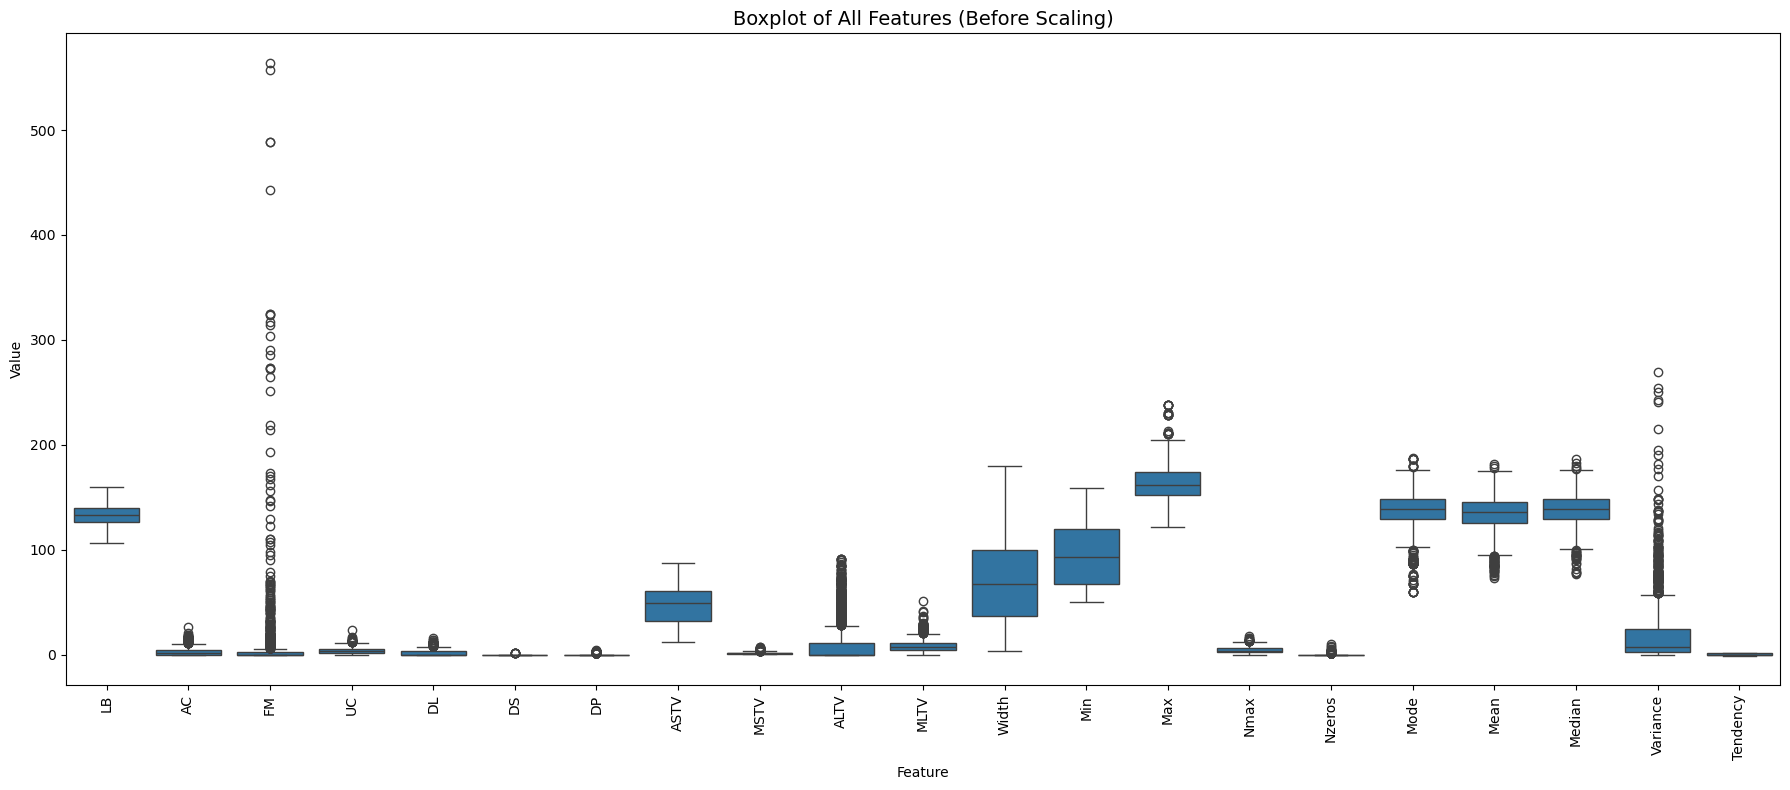

In [55]:
plt.figure(figsize=(18, 8))
X_melted = X_imputed.melt(var_name='Feature', value_name='Value')
sns.boxplot(data=X_melted, x='Feature', y='Value')
plt.xticks(rotation=90)
plt.title('Boxplot of All Features (Before Scaling)', fontsize=14)
plt.tight_layout()
plt.show()